In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from matplotlib_venn import venn2  
from scipy import stats  
import os  
from matplotlib.lines import Line2D  
from matplotlib import rcParams  
import gseapy as gp 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
from scipy import stats
from gseapy import barplot, dotplot
import os
from gseapy.plot import gseaplot2


# Create output directory for plots  
output_dir = '../neuron_core_essential/'  
if not os.path.exists(output_dir):  
    os.makedirs(output_dir)  

In [2]:
rcParams['font.family'] = 'sans-serif'  
rcParams['font.sans-serif'] = ['Arial']  
rcParams['font.size'] = 10 
rcParams['axes.linewidth'] = 0.8  
rcParams['xtick.major.width'] = 0.8  
rcParams['ytick.major.width'] = 0.8  
rcParams['xtick.major.size'] = 3  
rcParams['ytick.major.size'] = 3  
rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
rcParams['ps.fonttype'] = 42  
rcParams['svg.fonttype'] = 'none'  
rcParams['figure.dpi'] = 300  

In [3]:
month = ['2M', '4M']
cell_type = ['Vglut2', 'Syn1', 'Vgat', 'Emx1']
library = ['GW']
cell_type_essential = {}
for c in cell_type:
    cell_type_essential[c] = []
    for m in month:
        for l in library:
           
            screen = f'../new_mageck/{c}-{l}-all_{m}/{c}-{l}-all_{m}.gene_summary.txt'
            print (screen)
            df = pd.read_csv(screen, sep='\t', index_col=0)
            cell_type_essential[c] += df[df['hits']==-1]['gene'].tolist()
            cell_type_essential[c] = list(set(cell_type_essential[c]))

../new_mageck/Vglut2-GW-all_2M/Vglut2-GW-all_2M.gene_summary.txt
../new_mageck/Vglut2-GW-all_4M/Vglut2-GW-all_4M.gene_summary.txt
../new_mageck/Syn1-GW-all_2M/Syn1-GW-all_2M.gene_summary.txt
../new_mageck/Syn1-GW-all_4M/Syn1-GW-all_4M.gene_summary.txt
../new_mageck/Vgat-GW-all_2M/Vgat-GW-all_2M.gene_summary.txt
../new_mageck/Vgat-GW-all_4M/Vgat-GW-all_4M.gene_summary.txt
../new_mageck/Emx1-GW-all_2M/Emx1-GW-all_2M.gene_summary.txt
../new_mageck/Emx1-GW-all_4M/Emx1-GW-all_4M.gene_summary.txt


In [4]:
all_hits = [gene for i in cell_type_essential.values() for gene in i]
from collections import Counter
counts = Counter(all_hits)
df = pd.DataFrame(counts.items(), columns=['item', 'count'])


In [5]:
neuron_core_essential = df[df['count']>=3]['item'].tolist()

In [6]:
len(neuron_core_essential)

269

In [50]:
neuron_core_essential[neuron_core_essential.index('0610010K14Rik')] = "Bacc1"
neuron_core_essential[neuron_core_essential.index('Lars')] = "Lars1"

In [7]:
# Step 1: Define your gene list  
gene_list = neuron_core_essential
sample = 'neuron_core_essential'

# Step 2: Perform the KEGG enrichment analysis  
enrichment = gp.enrichr(  
    gene_list=gene_list,  
    gene_sets=['KEGG_2021_Human','Jensen_DISEASES_Curated_2025'],
#             background=background_genes,  
    cutoff=0.1,  no_plot = True, outdir = f'../neuron_core_essential/{sample}'# Adjust the cutoff value if needed  
)  


In [11]:
with open('../analysis/TableS2_essential_gene_hart_2017.txt', 'r') as f:
    hart_core_essential = [i.strip() for i in f]
# Step 1: Define your gene list  
gene_list = hart_core_essential
sample = 'hart_core_essential'

# Step 2: Perform the KEGG enrichment analysis  
enrichment = gp.enrichr(  
    gene_list=gene_list,  
    gene_sets=['KEGG_2021_Human', 'Jensen_DISEASES_Curated_2025'],
#             background=background_genes,  
    cutoff=0.1,  no_plot = True, outdir = f'../neuron_core_essential/{sample}'# Adjust the cutoff value if needed  
)  


In [68]:
with open('../neuron_core_essential/neuron_core_essential.txt','w') as f:
    for i in neuron_core_essential:
        f.write(i+'\n')

In [8]:
from gseapy import Biomart
bm = Biomart()
# note the dataset and attribute names are different
m2h = bm.query(dataset='mmusculus_gene_ensembl',
               attributes=['ensembl_gene_id','external_gene_name',
                           'hsapiens_homolog_ensembl_gene',
                           'hsapiens_homolog_associated_gene_name'])

In [18]:
mapping

{'mt-Tf': nan,
 'mt-Rnr1': nan,
 'mt-Tv': nan,
 'mt-Rnr2': nan,
 'mt-Tl1': nan,
 'mt-Nd1': 'MT-ND1',
 'mt-Ti': nan,
 'mt-Tq': nan,
 'mt-Tm': nan,
 'mt-Nd2': 'MT-ND2',
 'mt-Tw': nan,
 'mt-Ta': nan,
 'mt-Tn': nan,
 'mt-Tc': nan,
 'mt-Ty': nan,
 'mt-Co1': 'MT-CO1',
 'mt-Ts1': nan,
 'mt-Td': nan,
 'mt-Co2': 'MT-CO2',
 'mt-Tk': nan,
 'mt-Atp8': 'MT-ATP8',
 'mt-Atp6': 'MT-ATP6',
 'mt-Co3': 'MT-CO3',
 'mt-Tg': nan,
 'mt-Nd3': 'MT-ND3',
 'mt-Tr': nan,
 'mt-Nd4l': 'MT-ND4L',
 'mt-Nd4': 'MT-ND4',
 'mt-Th': nan,
 'mt-Ts2': nan,
 'mt-Tl2': nan,
 'mt-Nd5': 'MT-ND5',
 'mt-Nd6': 'MT-ND6',
 'mt-Te': nan,
 'mt-Cytb': 'MT-CYB',
 'mt-Tt': nan,
 'mt-Tp': nan,
 nan: nan,
 'Vmn1r186': nan,
 'Csprs': nan,
 'Gm16367': 'PRAMEF7',
 'Gm28489': nan,
 'Gm21867': nan,
 'Gm29448': nan,
 'Gm20816': 'SPIN2B',
 'Gm29447': nan,
 'Gm29446': nan,
 'Gm29452': nan,
 'Gm29451': nan,
 'Gm20817': 'SYCP3',
 'Gm28633': nan,
 'Gm21562': nan,
 'Gm29410': nan,
 'Gm28298': nan,
 'Gm21572': nan,
 'Gm28297': nan,
 'Gm21753': nan,
 'Gm

In [59]:
mapping = dict(zip(m2h['external_gene_name'], m2h['hsapiens_homolog_associated_gene_name']))
human_homolog_core_neuron_essential = []
for i in neuron_core_essential:
    if i in mapping.keys():
        if str(mapping[i]) != 'nan':
            human_homolog_core_neuron_essential.append(mapping[i])
        else:
            human_homolog_core_neuron_essential.append(i.upper())
    else:
        print (i)
        human_homolog_core_neuron_essential.append(i.upper())


human_homolog_core_neuron_essential[human_homolog_core_neuron_essential.index('CHMP4BP1')] = 'CHMP4B'



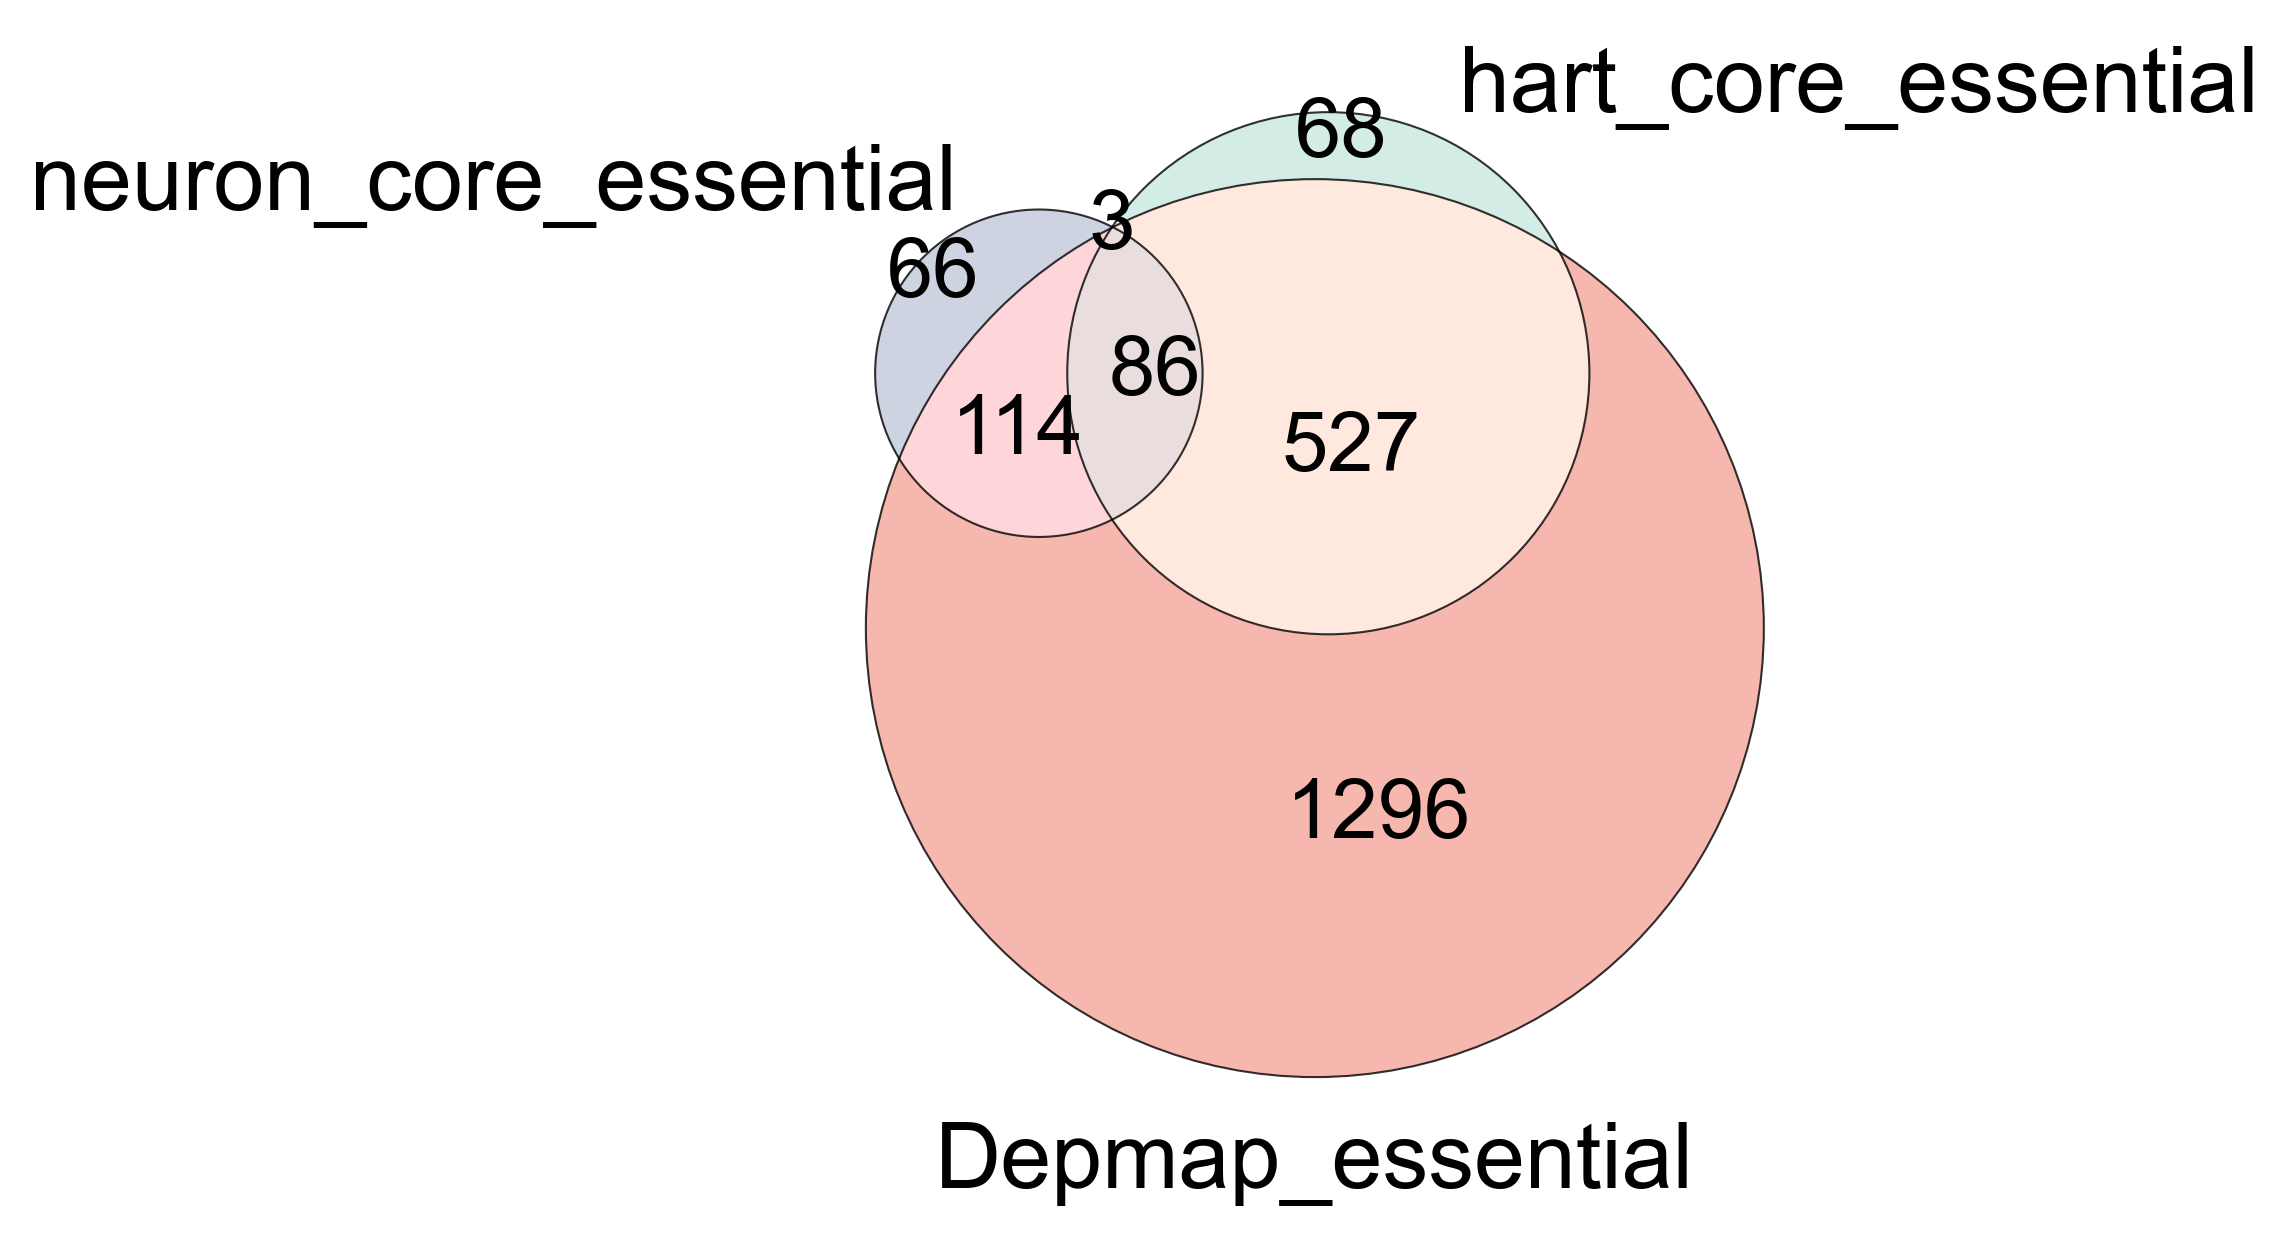

In [62]:
from matplotlib_venn import venn3,venn3_circles,venn2,venn2_circles

df_depmap = pd.read_csv('./CRISPRInferredCommonEssentials.csv')
depmap_es = df_depmap.iloc[:,1].tolist()

list1 = human_homolog_core_neuron_essential
list2 = hart_core_essential
list3 = depmap_es

plt.figure()
plt.rcParams['font.family'] = 'sans-serif'  
plt.rcParams['font.sans-serif'] = ['Arial']  
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 0.8  
plt.rcParams['xtick.major.width'] = 0.8  
plt.rcParams['ytick.major.width'] = 0.8  
plt.rcParams['xtick.major.size'] = 3  
plt.rcParams['ytick.major.size'] = 3  
plt.rcParams['pdf.fonttype'] = 42  # Ensures text is editable in AI  
plt.rcParams['ps.fonttype'] = 42  

out= venn3([set(list1),set(list2),set(list3)],set_colors=['#8491B4FF','#91D1C2FF','#E64B35FF'], 
           set_labels=['neuron_core_essential', 'hart_core_essential', 'Depmap_essential'])
for text in out.set_labels:
    text.set_fontsize(22)
for text in out.subset_labels:
    text.set_fontsize(20)
c = venn3_circles([set(list1),set(list2),set(list3)], linestyle='solid', linewidth=0.5, color="black")
# c[0].set_color('#E64B3599')
c[0].set_alpha(0.8)
# # c[1].set_color('#91D1C299')
c[1].set_alpha(0.8)
c[2].set_alpha(0.8)
# # c[2].set_color('#8491B499')
# c[2].set_alpha(0.8)
plt.tight_layout()
plt.savefig(f'../neuron_core_essential/neuron_vs_hart_vs_depmap_core_essential.pdf',bbox_inches='tight')

In [63]:
with open('../neuron_core_essential/neuron_core_essential_neuron_specific.txt','w') as f:
    for i in list(set(human_homolog_core_neuron_essential) - set(hart_core_essential) - set(depmap_es)):
        f.write(str(i)+'\n')
        
        